In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [4]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [5]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [6]:

# ==========================================
# HELPER FUNCTIONS (shared across all parts)
# ==========================================

def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3_000_000:
        print("  WARNING: You are over the 3M parameter limit!")
    else:
        print("  OK: Parameter count is within limits.")


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            loss = criterion(outputs, y)
            total_loss += loss.item() * X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return history


def plot_history(history, title="Training History"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()



Model Statistics:
  Total Parameters: 1,868,815
  OK: Parameter count is within limits.
Epoch   1/30 | Train Loss: 1.1863, Acc: 0.6124 | Val Loss: 0.9296, Acc: 0.6987
Epoch   2/30 | Train Loss: 0.8946, Acc: 0.7043 | Val Loss: 0.8498, Acc: 0.7274
Epoch   3/30 | Train Loss: 0.7844, Acc: 0.7383 | Val Loss: 0.7849, Acc: 0.7452
Epoch   4/30 | Train Loss: 0.6977, Acc: 0.7665 | Val Loss: 0.7589, Acc: 0.7546
Epoch   5/30 | Train Loss: 0.6261, Acc: 0.7876 | Val Loss: 0.7499, Acc: 0.7565
Epoch   6/30 | Train Loss: 0.5692, Acc: 0.8056 | Val Loss: 0.7324, Acc: 0.7646
Epoch   7/30 | Train Loss: 0.5256, Acc: 0.8180 | Val Loss: 0.7394, Acc: 0.7657
Epoch   8/30 | Train Loss: 0.4804, Acc: 0.8333 | Val Loss: 0.7417, Acc: 0.7681
Epoch   9/30 | Train Loss: 0.4374, Acc: 0.8466 | Val Loss: 0.7661, Acc: 0.7675
Epoch  10/30 | Train Loss: 0.4064, Acc: 0.8564 | Val Loss: 0.7921, Acc: 0.7643
Epoch  11/30 | Train Loss: 0.3033, Acc: 0.8919 | Val Loss: 0.7747, Acc: 0.7824
Epoch  12/30 | Train Loss: 0.2620, Acc: 0.

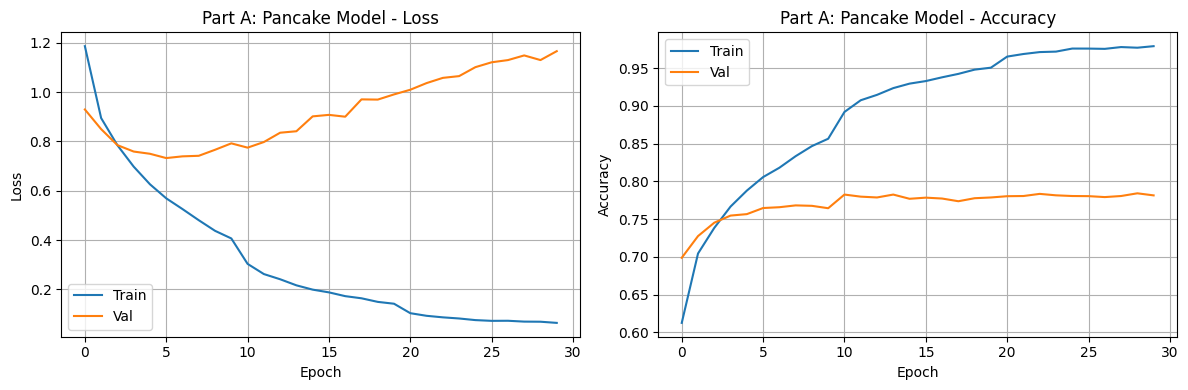

In [10]:

# ==========================================
# PART A: PANCAKE MODEL (Shallow & Wide)
# Architecture: 784 → 1024 → 1024 → 15
# 2 hidden layers, 1024 neurons each
# ==========================================

class PancakeModel(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# --- Verify parameter count ---
pancake_model = PancakeModel()
print_model_size(pancake_model)

# --- Train ---
PANCAKE_EPOCHS = 30
history_pancake = train_model(
    pancake_model, train_loader, val_loader,
    epochs=PANCAKE_EPOCHS, lr=1e-3
)

# --- Learning curves ---
plot_history(history_pancake, title="Part A: Pancake Model")

# Point 'model' to the best pancake model for the submission cell below
model = pancake_model



Model Statistics:
  Total Parameters: 669,455
  OK: Parameter count is within limits.
Epoch   1/30 | Train Loss: 1.6468, Acc: 0.4386 | Val Loss: 1.0697, Acc: 0.6392
Epoch   2/30 | Train Loss: 1.1727, Acc: 0.6130 | Val Loss: 0.9667, Acc: 0.6735
Epoch   3/30 | Train Loss: 1.0707, Acc: 0.6481 | Val Loss: 0.9057, Acc: 0.6937
Epoch   4/30 | Train Loss: 1.0196, Acc: 0.6653 | Val Loss: 0.9049, Acc: 0.6923
Epoch   5/30 | Train Loss: 0.9845, Acc: 0.6788 | Val Loss: 0.8457, Acc: 0.7163
Epoch   6/30 | Train Loss: 0.9478, Acc: 0.6909 | Val Loss: 0.8418, Acc: 0.7157
Epoch   7/30 | Train Loss: 0.9208, Acc: 0.6988 | Val Loss: 0.8267, Acc: 0.7270
Epoch   8/30 | Train Loss: 0.8927, Acc: 0.7126 | Val Loss: 0.7973, Acc: 0.7351
Epoch   9/30 | Train Loss: 0.8735, Acc: 0.7171 | Val Loss: 0.7764, Acc: 0.7413
Epoch  10/30 | Train Loss: 0.8482, Acc: 0.7278 | Val Loss: 0.7772, Acc: 0.7449
Epoch  11/30 | Train Loss: 0.7985, Acc: 0.7402 | Val Loss: 0.7447, Acc: 0.7571
Epoch  12/30 | Train Loss: 0.7763, Acc: 0.74

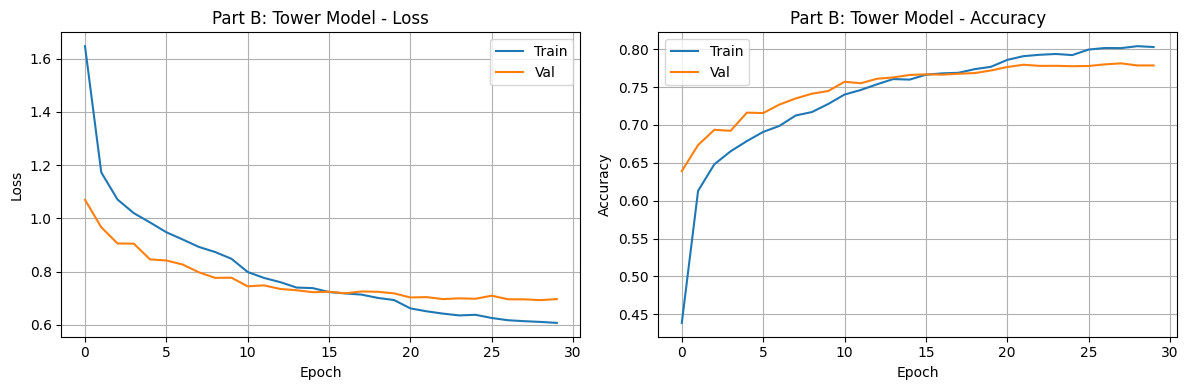

In [7]:

# ==========================================
# PART B: TOWER MODEL (Deep & Narrow)
# Architecture: 784 → [256 x 8] → 15
# 8 hidden layers, 256 neurons each
# BatchNorm after Linear, before ReLU
# No skip connections
# ==========================================

class TowerModel(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_layers=8, num_classes=15, dropout=0.3):
        super().__init__()

        layers = [nn.Flatten()]

        # Input layer
        layers += [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]

        # Hidden layers
        for _ in range(num_layers - 1):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]

        # Output layer
        layers.append(nn.Linear(hidden_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# --- Verify parameter count ---
tower_model = TowerModel(hidden_size=256, num_layers=8)
print_model_size(tower_model)

# --- Train ---
TOWER_EPOCHS = 30
history_tower = train_model(
    tower_model, train_loader, val_loader,
    epochs=TOWER_EPOCHS, lr=1e-3
)

# --- Learning curves ---
plot_history(history_tower, title="Part B: Tower Model")

# Update model reference for submission
model = tower_model



Model Statistics:
  Total Parameters: 2,924,559
  OK: Parameter count is within limits.


/home/sarmad/Documents/lums/lums/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch   1/40 | Train Loss: 2.1200, Acc: 0.3570 | Val Loss: 1.5437, Acc: 0.5924
Epoch   2/40 | Train Loss: 1.7095, Acc: 0.5229 | Val Loss: 1.3484, Acc: 0.6747
Epoch   3/40 | Train Loss: 1.5763, Acc: 0.5772 | Val Loss: 1.3244, Acc: 0.6812
Epoch   4/40 | Train Loss: 1.5212, Acc: 0.6030 | Val Loss: 1.2667, Acc: 0.7153
Epoch   5/40 | Train Loss: 1.4686, Acc: 0.6252 | Val Loss: 1.2385, Acc: 0.7229
Epoch   6/40 | Train Loss: 1.4282, Acc: 0.6441 | Val Loss: 1.1932, Acc: 0.7471
Epoch   7/40 | Train Loss: 1.3986, Acc: 0.6558 | Val Loss: 1.1605, Acc: 0.7551
Epoch   8/40 | Train Loss: 1.3771, Acc: 0.6659 | Val Loss: 1.1365, Acc: 0.7712
Epoch   9/40 | Train Loss: 1.3516, Acc: 0.6760 | Val Loss: 1.1249, Acc: 0.7748
Epoch  10/40 | Train Loss: 1.3309, Acc: 0.6870 | Val Loss: 1.1232, Acc: 0.7745
Epoch  11/40 | Train Loss: 1.3218, Acc: 0.6893 | Val Loss: 1.1123, Acc: 0.7740
Epoch  12/40 | Train Loss: 1.3038, Acc: 0.6969 | Val Loss: 1.0899, Acc: 0.7870
Epoch  13/40 | Train Loss: 1.2931, Acc: 0.7029 | Val

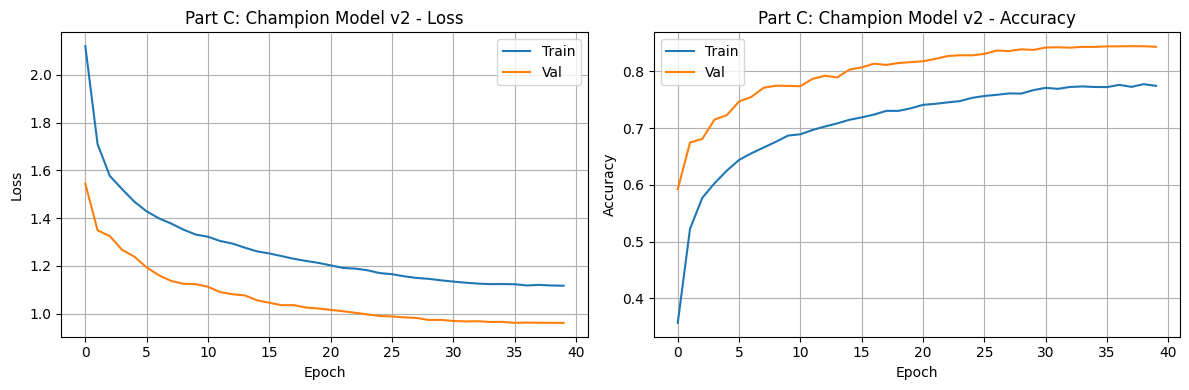

In [8]:

# ==========================================
# PART C: CHAMPION MODEL v2 (Improved)
# Key upgrades over v1:
#   1. Data augmentation (rotation, translate, erasing)
#   2. GELU activation
#   3. OneCycleLR scheduler
#   4. Test-Time Augmentation (TTA) at inference
# Architecture: 784 → 1024 → 1024 → 1024 → 15  (~2.92M params)
# ==========================================

from torchvision import transforms

# ------------------------------------------------------------------
# 1. AUGMENTED DATASET WRAPPER
# ------------------------------------------------------------------
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
            transforms.RandomAffine(
                degrees=12,
                translate=(0.10, 0.10),
                scale=(0.90, 1.10)
            ),
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.12), value=0),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]       # img: flat [784]
        img = img.view(1, 28, 28)            # → [1, 28, 28] for transforms
        img = self.transform(img)
        img = img.view(784)                  # → back to flat [784]
        return img, label

# Wrap training set with augmentation (val stays clean)
aug_train_dataset = AugmentedDataset(train_dataset)
aug_train_loader  = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)


# ------------------------------------------------------------------
# 2. MODEL
# ------------------------------------------------------------------
class ChampionModel(nn.Module):
    def __init__(self, input_size=784, hidden=1024, num_classes=15, dropout=0.35):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_size, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ------------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------------
def train_champion(model, train_loader, val_loader, epochs=40, lr=1e-3):
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # OneCycleLR: warms up then anneals — often best single-cycle schedule
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.1           # 10% warmup
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        # --- train ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            scheduler.step()          # OneCycleLR steps per batch
            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += X.size(0)
        train_loss = total_loss / total
        train_acc  = correct   / total

        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return history


# ------------------------------------------------------------------
# 4. TEST-TIME AUGMENTATION (TTA)
# ------------------------------------------------------------------
def get_predictions_tta(model, loader, n_aug=8):
    """Average softmax over n_aug augmented views of each test image."""
    model.eval()
    model.to(DEVICE)

    tta_tf = transforms.RandomAffine(degrees=10, translate=(0.05, 0.05))
    all_probs = None

    for i in range(n_aug):
        batch_probs = []
        with torch.no_grad():
            for batch in loader:
                X = batch.to(DEVICE)
                if i > 0:                           # pass 0 is clean
                    X2d  = X.view(-1, 1, 28, 28)
                    X2d  = torch.stack([tta_tf(x) for x in X2d])
                    X    = X2d.view(-1, 784)
                probs = torch.softmax(model(X), dim=1)
                batch_probs.append(probs.cpu())
        batch_probs = torch.cat(batch_probs, dim=0)
        all_probs   = batch_probs if all_probs is None else all_probs + batch_probs

    return all_probs.argmax(dim=1).tolist()


# ------------------------------------------------------------------
# 5. RUN
# ------------------------------------------------------------------
champion_model = ChampionModel()
print_model_size(champion_model)

history_champion = train_champion(
    champion_model, aug_train_loader, val_loader,
    epochs=40, lr=1e-3
)

plot_history(history_champion, title="Part C: Champion Model v2")

# Use TTA for the final submission
model = champion_model


In [ ]:
# ==========================================
# PART D: CONFUSION MATRIX (Champion Model)
# Run this cell after training champion_model
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, class_names, title="Confusion Matrix"):
    model.eval()
    model.to(DEVICE)
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            preds = model(X).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    n = len(class_names)

    # Build confusion matrix
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    # Normalise row-wise (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=13)

    # Annotate cells
    thresh = 0.5
    for i in range(n):
        for j in range(n):
            color = 'white' if cm_norm[i, j] > thresh else 'black'
            ax.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                    ha='center', va='center', fontsize=6.5, color=color)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

    # --- Top confused pairs ---
    off_diag = cm_norm.copy()
    np.fill_diagonal(off_diag, 0)
    top_idx = np.dstack(np.unravel_index(np.argsort(off_diag.ravel())[::-1], (n, n)))[0]
    print("\nTop 5 most confused pairs (true → predicted):")
    for true_i, pred_i in top_idx[:5]:
        print(f"  {class_names[true_i]:12s} → {class_names[pred_i]:12s}  "
              f"({cm[true_i, pred_i]} / {cm[true_i].sum()} = {cm_norm[true_i, pred_i]:.2%})")

    # Overall accuracy
    acc = (all_preds == all_labels).mean()
    print(f"\nValidation Accuracy: {acc:.4f} ({acc*100:.2f}%)")

plot_confusion_matrix(champion_model, val_loader, CLASSES,
                      title="Champion Model — Confusion Matrix (Validation Set)")


In [ ]:
import pandas as pd

# ==========================================
# 5. INFERENCE & LEADERBOARD SUBMISSION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)

test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Use TTA for best leaderboard score
print("Running inference with Test-Time Augmentation (TTA, n=8)...")
predictions = get_predictions_tta(model, test_loader, n_aug=8)

submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")
with open(submission_file, "w") as f:
    f.write(",".join(map(str, predictions)))
print(f"Done. Copy & paste the contents of submission.txt to the portal.")


In [ ]:
# print_model_size is defined in the Helper Functions cell above (cell 4)
